# He Initialization

Paper Link: https://arxiv.org/abs/1502.01852

In the paper, they introduce a parametric ReLU function: $$f(y_i) = \begin{cases} 
y_i, & \text{if } y_i > 0 \\ 
a_i y_i, & \text{if } y_i \leq 0 
\end{cases}$$
where $a_i$ is a learned parameter. This is not the focus of this notebook so I shall mostly ignore it.

---

- Improper weight initialization can hurt the training of deep NN
- They mention that there was a team that trained a smaller model first and used the final weights of that model as the starting weights for the larger model.
    - This is a pretty interesting idea. Obviously adds time to training though
- They talk about the Xavier initialization a bit, so it's like I'm getting a two for one here.
    - Xavier does not work well for ReLU networks

### Math Time!
We have the familiar $y_l = W_lx_l+b$ for each layer. Also denotes $n$ as the number of features in the input, so for the second layer it will be the number of neurons in the first layer. They start by initializing $b=0$ so the equation really becomes $y_l = \sum w_ix_i$

For independent variables A,B we have $Var(A+B)=Var(A)+Var(B)$ and since we assume that each connection is independent we get that $Var[y_l]=Var[\sum w_ix_i]=\sum Var[w_lx_l]$

So the variance of the entire layer is $Var[y_l]= \sum^{n_l}Var[w_lx_l]$  and since each $w_l$ and $x_l$ come from the same respective distribution we can write $Var[y_l]= n_l \cdot Var[w_lx_l]$ (since the variance is constant across all connections)

We also have $Var(AB) = E[A^2]E[B^2] - (E[A])^2(E[B])^2$ and so if we set the mean of $w_l$ to zero (only for initialization) we will obtain that $Var[w_lx_l]=E[w_l^2]E[x_l^2] - E[w_l]^2E[x_l]^2 = E[w_l^2]E[x_l^2]$ and once again the mean of $w_l$ is zero so $Var[w_l] = E[(w_l-0)^2]=E[w_l^2]$

So we obtain that $Var[y_l]=n_lVar[w_l]E[x_l^2]$. The authors note $E[x_l^2] \neq Var[x_l]$ since the mean of $x_l$ is not zero due to ReLU being the activation function.

Now we have to get $E[x_l^2]$. Remember that we are using ReLU so $x_l = max(0,y_{l-1})$. Since our $w_{l-1}$ is symmetric around 0, so is $y_{l-1}$ by linearity. The ReLU function takes half of $y_{l-1}$ and chops it off, so then $E[x_l^2] = \frac{1}{2}Var[y_{l-1}]$

Plugging in $E[x_l^2] = \frac{1}{2}Var[y_{l-1}]$ we get $Var[y_l] = 1/2 n_l Var[w_l]Var[y_{l-1}]$ which is a recursive relationship that simplifies to $Var[y_L]= Var[y_1](\prod_{l=2}^L \frac{1}{2} n_l Var[w_l])$. Intuitively, this tells us that the variance of a layer is a result of the variance and complexities of the previous layers. If the term inside the $\prod$ deviate from 1 then the variance of the final layer may explode or vanish, which will in turn cause the gradients to explode/vanish (not good!). They state that a proper intialization would satisfy $\frac{1}{2}n_lVar[w_l]=1, \space \forall l$

On a side note, I'm not fully sure why low variance of inputs is bad. One explanation that I got is that $w$ have mean 0, so do $y_l$ meaning that if variance is low for that then all the inputs are $x \approx 0$ which will vanish the gradients. Also even if mean is not 0, then the weights will all receive pretty much the same update, also not great. 

Our conditions in the walk-through were that $w$ had a symmetric distribution around 0, and now we need it to have variance to satisfy the above condition. This leads us to initialize our weights via zero-mean Gaussian distribution with std $\sqrt{2/n_l}$

There could be a practical issue that the scale of your input will be preserved throughout all of the layers. This is an issue if you are using a softmax layer for pixel data and your variance is preserved, you could end up calculating something like $e^{128}$ (for [-128,128] pixel range) which will clearly lead to numerical overflow. Normalizing the input should fix the issue.

### Code

*A solid amount of AI assistance will be used here because I'm not too familiar with PyTorch at the moment*

To be honest, there wasn't really any plan for the code part of this notebook. I just want to visualize and play around with some traits of the He initialization. Particularly, I want to see the math in action and if it holds true.

As I was designing this notebook, I realized that I don't really need to train a model to see the effects of the initialization. Which is pretty obvious in hindsight. For a second I considered to train a model in such a way that it only worked with proper initialization, but this is a waste of effort.

Instead, I decided that seeing if the model keeps the variance of the inputs relatively well and see how naive gaussian initialization does in this regard.

In [1]:
import numpy as np
import torch 
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets
import torchvision.transforms as transforms 
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

Let's import/download the Cifar-10 dataset for our experiments. They worked with CNN's in the paper so it's only right for us to use an image dataset.

In [2]:
trainset = torchvision.datasets.CIFAR10(
    root='data', 
    train=True, 
    download=True, 
    transform=transforms.ToTensor()
)

testset = torchvision.datasets.CIFAR10(
    root='data', 
    train=False, 
    download=True, 
    transform=transforms.ToTensor()
)

random_indices = np.random.choice(len(trainset), 500, replace=False)
train_subset = Subset(trainset, random_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(testset, batch_size=64, shuffle=True)

Files already downloaded and verified
Files already downloaded and verified


#### Model
Here we define the model. The architecture is just a series of a bunch of CNN's with some max pooling. And then we use a linear layer to output logits. Not a brilliant design, but for us we just want to have a semi-deep network. 

In [3]:
# This was mostly from AI. Thanks Gemini! 
class DeepNN(nn.Module):
    def __init__(self, num_layers=10, num_classes=10):
        super().__init__()
        layers = []
        in_channels = 3

        for i in range(num_layers):
            layers.append(nn.Conv2d(in_channels, 16, kernel_size=3, padding=1))
            layers.append(nn.ReLU(inplace=True))
            in_channels = 16
            if (i + 1) % 10 == 0:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        self.features = nn.Sequential(*layers)  
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1,)),
            nn.Flatten(),
            nn.Linear(16,num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#### Initialization
Now implementing this by hand is not necessary but I wanted to for learning purposes. I also wrote up a very vanilla Gaussian based initialization. 

In [4]:
def he_init(model_modules):
    for m in model_modules:
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            if isinstance(m, nn.Conv2d):
                n = m.in_channels * m.kernel_size[0] * m.kernel_size[1]
            else:
                n = m.in_features
                
            std = np.sqrt(2.0/n)
            
            m.weight.data.normal_(0,std)
            m.bias.data.zero_()

def gauss_init(model_modules):
    for m in model_modules:
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            m.weight.data.normal_(0,0.01)
            m.bias.data.zero_()

#### Train
Basic train loop, but we keep track of first and last gradient to check out the gradient flow of the model. 

In [5]:
def train(dataloader, model, loss_fn, optimizer, print_freq=100):
    model.train()
    size = len(dataloader.dataset)
    loss_history = []
    first_layer_grad_history = []
    last_layer_grad_history = []
    
    for batch, (x,y) in enumerate(dataloader):
        pred = model(x)
        loss = loss_fn(pred, y)
        loss_history.append(loss.item())

        loss.backward()
        if batch % print_freq == 0:
            first_layer_grad_history.append(model.features[0].weight.grad.abs().mean().item())
            last_layer_grad_history.append(model.classifier[2].weight.grad.abs().mean().item())
            
            loss, current = loss.item(), batch * batch_size + len(x)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
            
        optimizer.step()
        optimizer.zero_grad()

    return loss_history, first_layer_grad_history, last_layer_grad_history
        

def test(dataloader, model, loss_fn):
    model.eval()
    test_loss,correct = 0,0
    
    with torch.no_grad():
        for x,y in dataloader:
            pred = model(x)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= len(dataloader)
    correct /= len(dataloader.dataset)

    print(f"Test Loss: {test_loss} \n Test Accuracy: {correct}")
    return test_loss, correct

Here are some functions to test out the math that was described in the paper. 

I didn't mention it above but the refer to the factor inside the product in the equation for variance of a layer as beta, i.e. $\beta = \frac{1}{2} n_l Var[y_l]$. If we want the variance of the input to be maintained then we want the $\beta$ values to be 1. 

Additionally, we have a function that calculates the variance of the input and the variance of each layer when that input is being processed through the network. 

In [6]:
def calculate_betas(model):
    betas = []
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            n = m.in_channels * m.kernel_size[0] * m.kernel_size[1]
            weights_var = m.weight.var()

            betas.append(0.5 * n * weights_var.item())

    return betas

def get_activation_variances(model, input_batch):
    model.eval() 
    variances = []
    
    current_x = input_batch
    variances.append(current_x.var().item())
    
    with torch.no_grad():
        for layer in model.features:
            current_x = layer(current_x)
            
            if isinstance(layer, torch.nn.ReLU): # only add variances after ReLU
                variances.append(current_x.var().item())
                
    return variances


#### Experiment Time
We are going to init two models, one with `he_init` and one with `gauss_init` and then see how they do at maintaining the variances and what their beta values are. 

Then we will train the model a little and see if we notice any trends there.

In [7]:
num_layers = 10
learning_rate = 0.1
batch_size = 64
num_epochs = 50

he_model = DeepNN(num_layers=num_layers)
he_init(he_model.modules())

non_he_model = DeepNN(num_layers=num_layers)
gauss_init(non_he_model.modules())

Aha. The variances don't really fluctuate with the `he_init` which is the result we should be seeing. On the other hand, using the vanilla init that I wrote the variances change by 10+ orders of magnitudes. 

The betas also behave as we expect

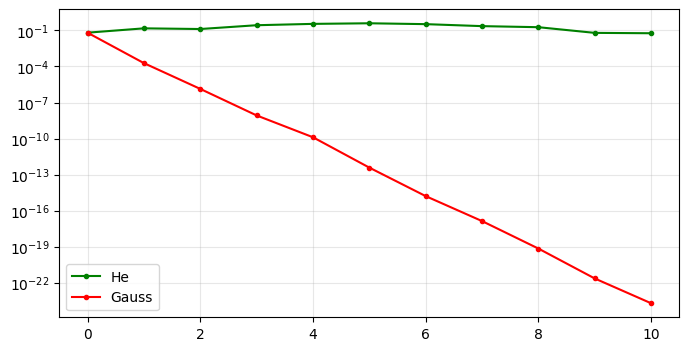

In [8]:
x,y = next(iter(test_loader))

he_vars = get_activation_variances(he_model,x)
non_he_vars = get_activation_variances(non_he_model,x) 

plt.figure(figsize=(8, 4))
plt.plot(he_vars, label='He', color='green', marker='.')
plt.plot(non_he_vars, label='Gauss', color='red', marker='.')

plt.yscale('log')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

In [9]:
print(calculate_betas(he_model))
print("--------------------------------------")
print(calculate_betas(non_he_model))

[1.1051076650619507, 1.0102406814694405, 1.0574103444814682, 1.0234422460198402, 1.0311383083462715, 0.9809065014123917, 0.9735007882118225, 1.009516216814518, 0.9930719956755638, 1.0469953939318657]
--------------------------------------
[0.0013518592750187963, 0.007251112663652748, 0.007442016270942986, 0.007135727384593338, 0.007194909383542836, 0.0073232955182902515, 0.00745083560468629, 0.006855598418042064, 0.007209294300992042, 0.007281386002432555]


In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(he_model.parameters(), lr=learning_rate)
he_loss_history = []
he_first_history = []
he_last_history = []

for _ in range(num_epochs):
    loss,first,last = train(train_loader, he_model, loss_fn, optimizer, print_freq=100)
    he_loss_history += loss
    he_first_history += first
    he_last_history += last

loss: 2.313292  [   64/  500]
loss: 2.296266  [   64/  500]
loss: 2.336134  [   64/  500]
loss: 2.307986  [   64/  500]
loss: 2.290611  [   64/  500]
loss: 2.301083  [   64/  500]
loss: 2.321465  [   64/  500]
loss: 2.288731  [   64/  500]
loss: 2.379328  [   64/  500]
loss: 2.296378  [   64/  500]
loss: 2.277534  [   64/  500]
loss: 2.303772  [   64/  500]
loss: 2.266090  [   64/  500]
loss: 2.220291  [   64/  500]
loss: 2.304658  [   64/  500]
loss: 2.291052  [   64/  500]
loss: 2.303332  [   64/  500]
loss: 2.282170  [   64/  500]
loss: 2.302468  [   64/  500]
loss: 2.310304  [   64/  500]
loss: 2.295327  [   64/  500]
loss: 2.285528  [   64/  500]
loss: 2.292876  [   64/  500]
loss: 2.300044  [   64/  500]
loss: 2.302789  [   64/  500]
loss: 2.289171  [   64/  500]
loss: 2.294361  [   64/  500]
loss: 2.291528  [   64/  500]
loss: 2.293597  [   64/  500]
loss: 2.305352  [   64/  500]
loss: 2.283423  [   64/  500]
loss: 2.283055  [   64/  500]
loss: 2.267829  [   64/  500]
loss: 2.27

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(non_he_model.parameters(), lr=learning_rate)
loss_history = []
first_history = []
last_history = []

for _ in range(num_epochs):
    loss,first,last = train(train_loader, non_he_model, loss_fn, optimizer, print_freq=100)
    loss_history += loss
    first_history += first
    last_history += last

loss: 2.307067  [   64/  500]
loss: 2.299567  [   64/  500]
loss: 2.294057  [   64/  500]
loss: 2.294151  [   64/  500]
loss: 2.300095  [   64/  500]
loss: 2.285300  [   64/  500]
loss: 2.295222  [   64/  500]
loss: 2.307989  [   64/  500]
loss: 2.296104  [   64/  500]
loss: 2.315761  [   64/  500]
loss: 2.289189  [   64/  500]
loss: 2.277533  [   64/  500]
loss: 2.292934  [   64/  500]
loss: 2.316878  [   64/  500]
loss: 2.311180  [   64/  500]
loss: 2.308350  [   64/  500]
loss: 2.290408  [   64/  500]
loss: 2.296934  [   64/  500]
loss: 2.302277  [   64/  500]
loss: 2.311704  [   64/  500]
loss: 2.310235  [   64/  500]
loss: 2.329503  [   64/  500]
loss: 2.303188  [   64/  500]
loss: 2.283794  [   64/  500]
loss: 2.304745  [   64/  500]
loss: 2.308552  [   64/  500]
loss: 2.294571  [   64/  500]
loss: 2.300702  [   64/  500]
loss: 2.278333  [   64/  500]
loss: 2.291621  [   64/  500]
loss: 2.296217  [   64/  500]
loss: 2.322610  [   64/  500]
loss: 2.282125  [   64/  500]
loss: 2.29

In [13]:
def plot(loss,first,last):
    plt.figure(figsize=(12,5))
    plt.subplot(1, 2, 1)
    plt.plot(loss, color='tab:blue', label='Batch Loss')
    plt.title('Training Loss')
    plt.xlabel('Batch Iteration')
    plt.ylabel('Loss Value')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(first, label='First Layer (Conv1)', color='tab:red', alpha=0.8)
    plt.plot(last, label='Last Layer (Linear)', color='tab:green', alpha=0.8)
    
    plt.yscale('log') 
    
    plt.title('Gradient Flow (Mean Abs)')
    plt.xlabel('Batch Iteration')
    plt.ylabel('Magnitude (Log Scale)')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
        
    plt.tight_layout()


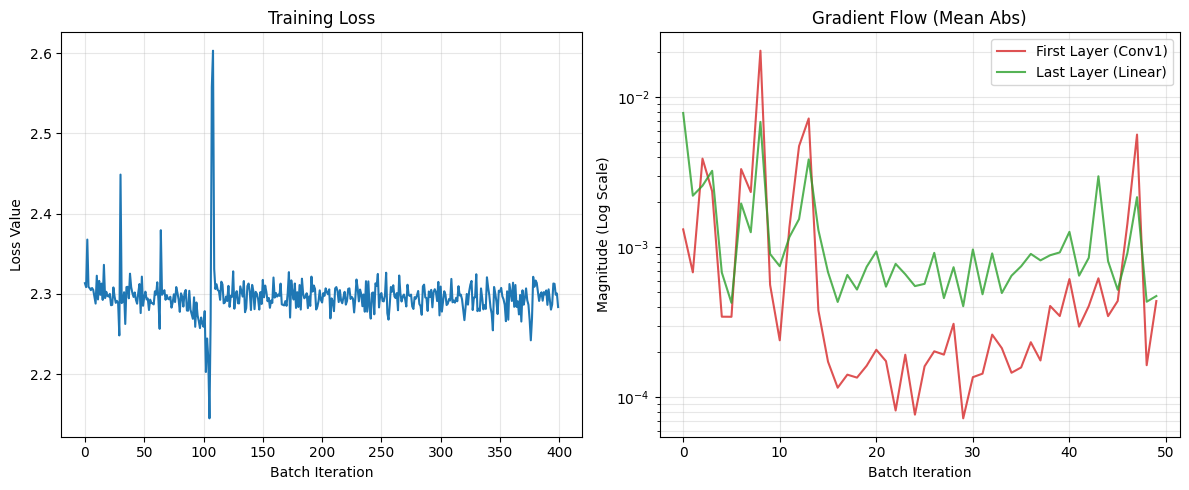

In [14]:
plot(he_loss_history, he_first_history, he_last_history)

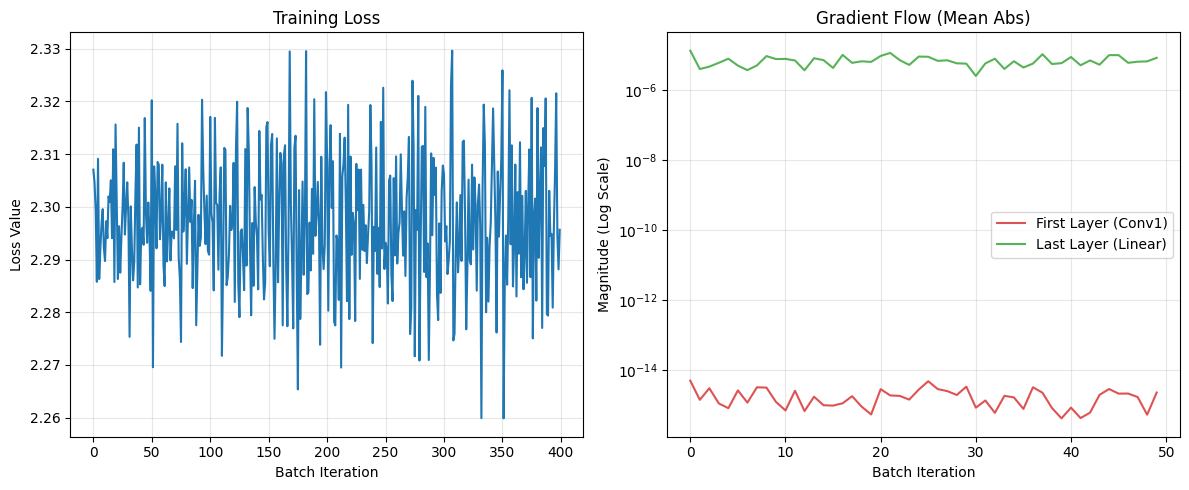

In [15]:
plot(loss_history, first_history, last_history) # gauss_init

Not sure how to interpret the loss histories, will probably come back to this at another time. But the gradient flow is cool too see, how vast the difference is between the two initializations. Something that seems so trivial can have such a profound impact on model training. I also read that BatchNorm and a lot of other techniques kind of remedy the effects of improper initializations which could be an interesting idea for a future experiment. 